https://cs231n.github.io/convolutional-networks/
https://www.geeksforgeeks.org/implementation-of-a-cnn-based-image-classifier-using-pytorch/

In [1]:
pip install torch torchvision torchaudio numpy matplotlib

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

Step 1: Loading CIFAR-10 from Google Drive (no torchvision download)

We use the **CIFAR-10 python version** (`cifar-10-python.tar.gz`, 163 MB, md5 `c58f30108f718f92721af3b95e74349a`).
Upload that file to your Drive, set `DRIVE_TAR` below to its path, and the cell will extract it and build
`train_dataset` / `test_dataset` objects that behave exactly like `torchvision.datasets.CIFAR10`
(same `__getitem__`, same `class_to_idx`), so every later cell works unchanged.

In [ ]:
import os, pickle, tarfile
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ---- Mount Google Drive (skip if running locally) ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not on Colab - make sure DRIVE_TAR points to a local path")

# ---- Path to the CIFAR-10 *python version* archive in your Drive ----
DRIVE_TAR   = '/content/drive/MyDrive/cifar-10-python.tar.gz'
EXTRACT_DIR = './CIFAR10'

# ---- Extract once ----
data_root = os.path.join(EXTRACT_DIR, 'cifar-10-batches-py')
if not os.path.isdir(data_root):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with tarfile.open(DRIVE_TAR, 'r:gz') as tar:
        tar.extractall(EXTRACT_DIR)
print("Data at:", data_root, "->", sorted(os.listdir(data_root)))

# ---- Defining plotting settings ----
plt.rcParams['figure.figsize'] = 14, 6

# ---- Normalizing transform (unchanged) ----
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5),
                                     std=(0.5, 0.5, 0.5))])

def _unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

class CIFAR10Local(torch.utils.data.Dataset):
    """Drop-in replacement for torchvision.datasets.CIFAR10 reading the
    extracted python-version batch files."""
    def __init__(self, root, train=True, transform=None):
        self.transform = transform
        files = [f'data_batch_{i}' for i in range(1, 6)] if train else ['test_batch']

        imgs, labels = [], []
        for fname in files:
            d = _unpickle(os.path.join(root, fname))
            imgs.append(d[b'data'])
            labels += d[b'labels']

        # (N, 3072) flat -> (N, 32, 32, 3) HWC uint8
        self.data = np.concatenate(imgs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        self.targets = labels

        meta = _unpickle(os.path.join(root, 'batches.meta'))
        self.classes = [c.decode('utf-8') for c in meta[b'label_names']]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.fromarray(self.data[idx])      # PIL, same as torchvision
        if self.transform is not None:
            img = self.transform(img)
        return img, self.targets[idx]

# ---- Building train and test sets from the local files ----
train_dataset = CIFAR10Local(data_root, train=True,  transform=normalize_transform)
test_dataset  = CIFAR10Local(data_root, train=False, transform=normalize_transform)
print(len(train_dataset), "train images |", len(test_dataset), "test images")

# ---- Generating data loaders from the corresponding datasets ----
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size)

# ---- Plotting 25 images from the 1st batch ----
dataiter = iter(train_loader)
images, labels = next(dataiter)     # .next() is removed in newer PyTorch
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')


Step-2: Plotting class distribution of the dataset

It’s generally a good idea to plot out the class distribution of the training set. This helps in checking whether the provided dataset is balanced or not. To do this, we iterate over the entire training set in batches and collect the respective classes of each instance. Finally, we calculate the counts of the unique classes and plot them.

In [ ]:
#Iterating over the training dataset and storing the target class for each sample
classes = []
for batch_idx, data in enumerate(train_loader, 0):
	x, y = data
	classes.extend(y.tolist())

#Calculating the unique classes and the respective counts and plotting them
unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")


Implementing the CNN architecture

On the architecture side, we’ll be using a simple model that employs three convolution layers with depths 32, 64, and 64, respectively, followed by two fully connected layers for performing classification.

Each convolutional layer involves a convolutional operation involving a 3×3 convolution filter and is followed by a ReLU activation operation for introducing nonlinearity into the system and a max-pooling operation with a 2×2 filter to reduce the dimensionality of the feature map.
After the end of the convolutional blocks, we flatten the multidimensional layer into a low dimensional structure for starting our classification blocks. After the first linear layer, the last output layer(also a linear layer) has ten neurons for each of the ten unique classes in our dataset.
The architecture is as follows:


Figure 3: Architecture of the CNN

For building our model, we’ll make a CNN class inherited from the torch.nn.Module class for taking advantage of the Pytorch utilities. Apart from that, we’ll be using the torch.nn.Sequential container to combine our layers one after the other.

The Conv2D(), ReLU(), and MaxPool2D() layers perform the convolution, activation, and pooling operations. We used padding of 1 to give sufficient learning space to the kernel as padding gives the image more coverage area, especially the pixels in the outer frame.
After the convolutional blocks, the Linear() fully connected layers perform classification.

In [4]:
class CNN(torch.nn.Module):
	def __init__(self):
		super().__init__()
		self.model = torch.nn.Sequential(
			#Input = 3 x 32 x 32, Output = 32 x 32 x 32
			torch.nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, padding = 1),
			torch.nn.ReLU(),
			#Input = 32 x 32 x 32, Output = 32 x 16 x 16
			torch.nn.MaxPool2d(kernel_size=2),

			#Input = 32 x 16 x 16, Output = 64 x 16 x 16
			torch.nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1),
			torch.nn.ReLU(),
			#Input = 64 x 16 x 16, Output = 64 x 8 x 8
			torch.nn.MaxPool2d(kernel_size=2),

			#Input = 64 x 8 x 8, Output = 64 x 8 x 8
			torch.nn.Conv2d(in_channels = 64, out_channels = 64, kernel_size = 3, padding = 1),
			torch.nn.ReLU(),
			#Input = 64 x 8 x 8, Output = 64 x 4 x 4
			torch.nn.MaxPool2d(kernel_size=2),

			torch.nn.Flatten(),
			torch.nn.Linear(64*4*4, 512),
			torch.nn.ReLU(),
			torch.nn.Linear(512, 10)
		)

	def forward(self, x):
		return self.model(x)


Step-4: Defining the training parameters and beginning the training process

We begin the training process by selecting the device to train our model onto, i.e., CPU or a GPU. Then, we define our model hyperparameters which are as follows:

We train our models over 50 epochs, and since we have a multiclass problem, we used the Cross-Entropy Loss as our objective function.
We used the popular Adam optimizer with a learning rate of 0.001 and weight_decay of 0.01 to prevent overfitting through regularization to optimize the objective function.
Finally, we begin our training loop, which involves calculating outputs for each batch and the loss by comparing the predicted labels with the true labels. In the end, we’ve plotted the training loss for each respective epoch to ensure the training process went as per the plan.

Epoch 1/2: Training loss = 1.6333694470203137
Epoch 2/2: Training loss = 1.3579750588482908


Text(0, 0.5, 'Training loss')

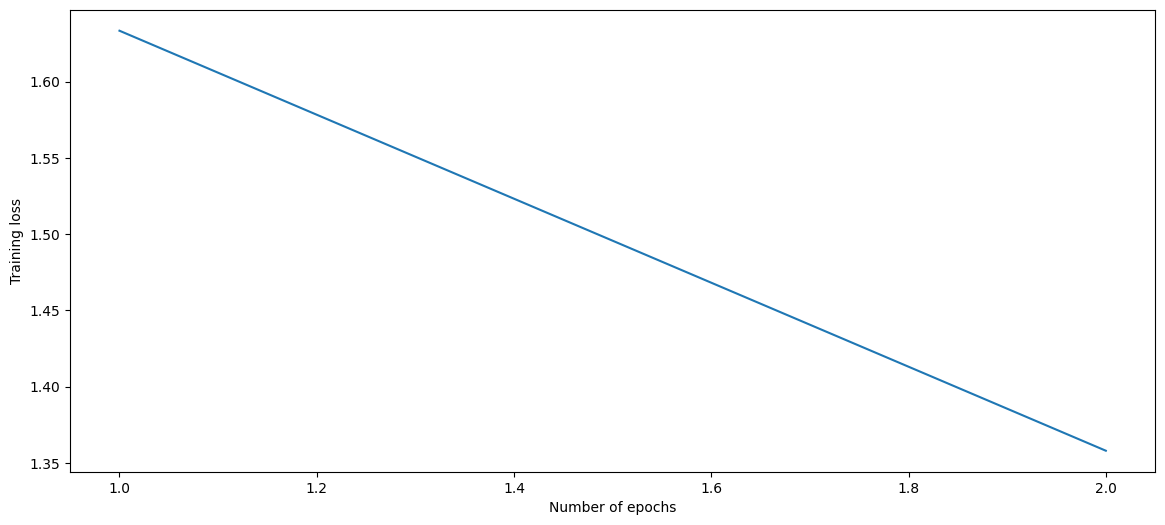

In [14]:
#Selecting the appropriate training device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)

#Defining the model hyper parameters
num_epochs = 2
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

#Training process begins
train_loss_list = []
for epoch in range(num_epochs):
	print(f'Epoch {epoch+1}/{num_epochs}:', end = ' ')
	train_loss = 0

	#Iterating over the training dataset in batches
	model.train()
	for i, (images, labels) in enumerate(train_loader):

		#Extracting images and target labels for the batch being iterated
		images = images.to(device)
		labels = labels.to(device)

		#Calculating the model output and the cross entropy loss
		outputs = model(images)
		loss = criterion(outputs, labels)

		#Updating weights according to calculated loss
		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		train_loss += loss.item()

	#Printing loss for each epoch
	train_loss_list.append(train_loss/len(train_loader))
	print(f"Training loss = {train_loss_list[-1]}")

#Plotting loss for all epochs
plt.plot(range(1,num_epochs+1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")


Step-5: Calculating the model’s accuracy on the test set

Now that our model’s trained, we need to check its performance on the test set. To do that, we iterate over the entire test set in batches and calculate the accuracy score by comparing the true and predicted labels for each batch.

In [15]:
test_acc=0
model.eval()

with torch.no_grad():
	#Iterating over the training dataset in batches
	for i, (images, labels) in enumerate(test_loader):

		images = images.to(device)
		y_true = labels.to(device)

		#Calculating outputs for the batch being iterated
		outputs = model(images)

		#Calculated prediction labels from models
		_, y_pred = torch.max(outputs.data, 1)

		#Comparing predicted and true labels
		test_acc += (y_pred == y_true).sum().item()

	print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")


Test set accuracy = 55.29 %


Step 6: Generating predictions for sample images in the test set

As shown in Figure 5, our model has achieved an accuracy of nearly 72%. To validate its performance, we can generate some predictions for some sample images. To do that, we take the first five images of the last batch of the test set and plot them using the make_grid utility from torchvision. We then collect their true labels and predictions from the model and show them in the plot’s title.

(-0.5, 231.5, 33.5, -0.5)

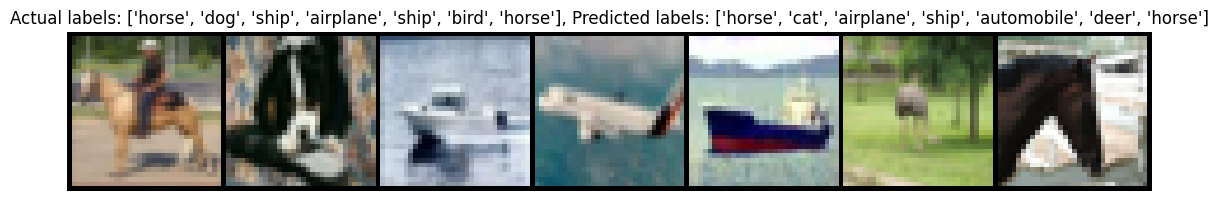

In [16]:
#Generating predictions for 'num_images' amount of images from the last batch of test set
num_images = 7
y_true_name = [names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]

#Generating the title for the plot
title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

#Finally plotting the images with their actual and predicted labels in the title
plt.imshow(np.transpose(torchvision.utils.make_grid(images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")


As can be seen from Figure , the model is producing correct predictions for all the images except the 2nd one as it misclassifies the dog as a cat!